# 01 — Perception Control

> **"Visualization is not about showing data. It is about controlling what the viewer sees first."**

---

Bộ não con người không đọc chart một cách bình đẳng.
Nó bị thu hút bởi màu sắc nổi bật, độ tương phản cao, và vị trí nổi bật hơn.

**Perception Control** là kỹ thuật dùng các thuộc tính thị giác (màu sắc, độ mờ, độ dày, thứ tự lớp)
để chủ động điều hướng ánh nhìn của người xem đến đúng nơi cần quan tâm.

### Nội dung notebook này:

1. **Signal vs Noise** — Tách tín hiệu ra khỏi nhiễu
2. **Highlight** — Làm nổi bật series / điểm / vùng quan trọng
3. **Fade** — Đẩy nền xuống background
4. **Focus** — Thu hẹp sự chú ý vào một khoảng thời gian
5. **Visual Hierarchy** — Phân cấp thị giác: primary / secondary / background
6. **Saliency** — Encode mức độ quan trọng bằng kích thước và màu
7. **Outlier Emphasis** — Làm nổi bật điểm dị thường

## Setup

In [14]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.use('Agg')
%matplotlib inline

# --- vizint imports ---
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

from vizint.core import ChartBuilder, despine, set_grid
from vizint.perception import (
    highlight_series, highlight_region, highlight_points,
    fade_series, fade_background_lines,saliency_map_scatter,
)
from vizint.annotation import label_last_point, add_note

np.random.seed(42)
print('Setup OK ✓')

Setup OK ✓


## Synthetic Data

Tạo dữ liệu giả lập: 5 series đại diện cho 5 công ty trong cùng ngành.
Một trong số đó là **signal** (công ty chúng ta quan tâm), 4 còn lại là **noise** (background context).

In [15]:
T = 60  # 60 tháng = 5 năm
t = np.arange(T)

# 4 background companies — random walks
bg_series = {
    'Company B': 100 + np.cumsum(np.random.randn(T) * 1.5),
    'Company C': 100 + np.cumsum(np.random.randn(T) * 1.8),
    'Company D': 100 + np.cumsum(np.random.randn(T) * 1.2),
    'Company E': 100 + np.cumsum(np.random.randn(T) * 1.6),
}

# Signal company — grows faster, then drops, then recovers
trend     = 0.5 * t
shock     = np.where(t >= 40, -20, 0)
recovery  = np.where(t >= 48, 1.2 * (t - 48), 0)
noise_sig = np.random.randn(T) * 1.0
y_signal  = 100 + trend + shock + recovery + noise_sig

print(f'Time steps : {T}')
print(f'Signal range: [{y_signal.min():.1f}, {y_signal.max():.1f}]')
print(f'Background series: {list(bg_series.keys())}')

Time steps : 60
Signal range: [99.2, 123.3]
Background series: ['Company B', 'Company C', 'Company D', 'Company E']


## 1. Signal vs Noise

### Problem
Khi plot nhiều time series với cùng một style trực quan, người xem sẽ không biết nên tập trung vào đâu.
Tất cả các đường đều cạnh tranh sự chú ý, tạo ra **visual noise** và làm giảm khả năng diễn giải biểu đồ.

Tình huống này thường xảy ra khi:
- plot nhiều model outputs
- overlay các simulations
- hiển thị bootstrap samples
- visualize ensemble predictions
- vẽ raw signal cùng với smoothed signal

Khi không có visual hierarchy, biểu đồ sẽ truyền tải **mọi thứ ngang nhau**, dẫn đến việc **không có thông tin nào nổi bật**.

---

### Solution
Tạo **visual hierarchy** bằng cách tách thành hai lớp:

- **Signal** → đường quan trọng được nhấn mạnh (`highlight_series`)
- **Noise** → các đường phụ được làm mờ (`fade_series`)

Sự tương phản giữa hai lớp này giúp mắt người:
- tập trung ngay vào đường chính
- vẫn giữ được context tổng thể
- tránh overload thị giác
- cải thiện interpretability

---

### Visual Encoding

Signal nên được nhấn mạnh bằng:
- màu đậm hơn
- linewidth lớn hơn
- opacity cao
- z-order cao
- label rõ ràng

Noise nên được làm mờ bằng:
- màu xám hoặc màu nhạt
- linewidth nhỏ
- alpha thấp
- không label
- z-order thấp

---

### Example

Before (No hierarchy):
- all lines: same color, same width, same alpha
→ viewer confused


After (Signal vs Noise):

- signal: bold blue line
- noise: thin gray lines (alpha=0.2)

→ viewer immediately sees main trend


---

### Why This Works

Nguyên lý này dựa trên:
- pre-attentive processing
- contrast-driven attention
- figure-ground separation
- visual hierarchy

Mắt người tự động chú ý đến:
- màu đậm hơn
- đường dày hơn
- độ tương phản cao hơn

Do đó chỉ cần thay đổi style, không cần thêm annotation.

---

### Design Rule

Always:
- highlight the message
- fade the context
- never treat all series equally

> If everything is important, nothing is important.

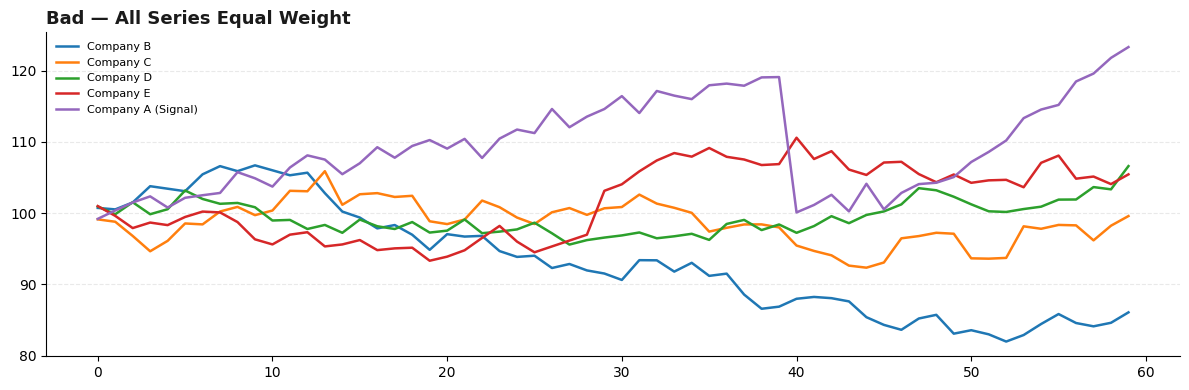

In [16]:
# ── BAD: tất cả series đều như nhau ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4), facecolor='white')

for name, y in bg_series.items():
    ax.plot(t, y, linewidth=1.8, label=name)
ax.plot(t, y_signal, linewidth=1.8, label='Company A (Signal)')

ax.legend(frameon=False, fontsize=8)
ax.set_title('Bad — All Series Equal Weight', loc='left',
             fontsize=13, fontweight='bold', color='#1a1a1a')
despine(ax)
set_grid(ax)
plt.tight_layout()
plt.show()

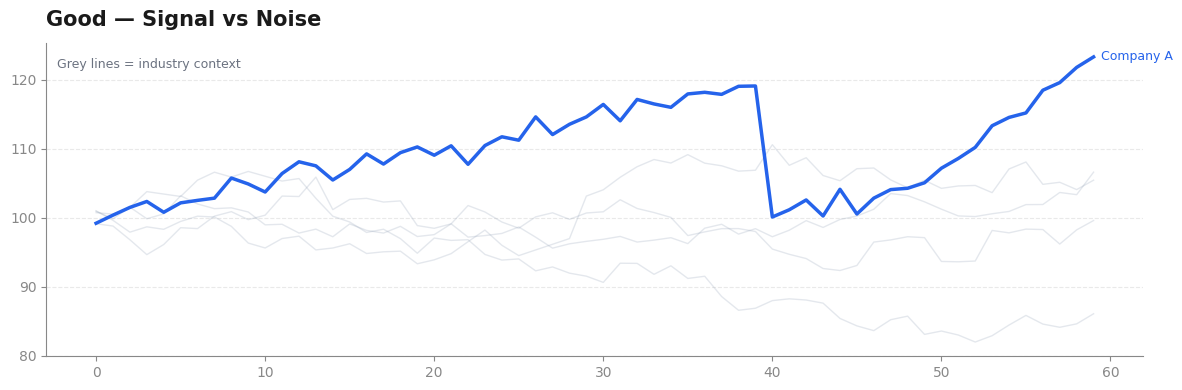

In [17]:
# ── GOOD: signal nổi, noise mờ ──────────────────────────────────────────────
chart = ChartBuilder(figsize=(12, 4)).set_title('Good — Signal vs Noise').build()
ax = chart.ax

# Noise — faded background
for name, y in bg_series.items():
    fade_series(ax, t, y, color='#94A3B8', alpha=0.25, linewidth=1.0)

# Signal — highlighted
highlight_series(ax, t, y_signal, color='#2563EB', linewidth=2.5)
label_last_point(ax, t, y_signal, text='Company A', color='#2563EB')

add_note(ax, 'Grey lines = industry context', x=0.01, y=0.95)
plt.tight_layout()
plt.show()

### Nhận xét

Cách tách **signal** và **noise** giúp biểu đồ có trọng tâm rõ ràng.
Series quan trọng nổi bật ngay lập tức, trong khi các series còn lại vẫn giữ vai trò cung cấp bối cảnh.

### Ưu điểm

- làm nổi bật series chính ngay lập tức
- giảm nhiễu thị giác từ các đường phụ
- không cần đọc legend vẫn hiểu trọng tâm
- giữ được context tổng thể của dữ liệu
- tránh cạnh tranh chú ý giữa các series
- cải thiện khả năng đọc khi có nhiều đường

### Lợi ích

- người xem hiểu insight nhanh hơn
- biểu đồ truyền đạt message rõ ràng hơn
- phù hợp khi highlight một đối tượng trong nhiều đối tượng
- dễ mở rộng khi số lượng series tăng
- giữ cân bằng giữa focus và context

## 2. Highlight — Series / Points / Region

### Nhận xét

Các kỹ thuật highlight giúp điều hướng sự chú ý đến đúng phần quan trọng của dữ liệu.
Tùy mục tiêu, có thể nhấn mạnh toàn bộ series, một số điểm cụ thể, hoặc một giai đoạn thời gian.

### highlight_series

Làm nổi bật một đường so với các đường còn lại.

Ưu điểm:
- xác định rõ series cần theo dõi
- tránh cạnh tranh thị giác giữa nhiều đường
- phù hợp khi muốn nhấn mạnh một đối tượng chính
- vẫn giữ được các series khác làm context

Lợi ích:
- người xem tập trung ngay vào xu hướng chính
- dễ so sánh signal với phần còn lại
- biểu đồ rõ ràng hơn khi có nhiều series

---

### highlight_points

Đánh dấu các điểm cụ thể bằng markers (scatter).

Ưu điểm:
- nhấn mạnh các điểm quan trọng trên đường
- phù hợp để highlight outliers hoặc events
- không làm thay đổi toàn bộ series
- giữ nguyên cấu trúc biểu đồ

Lợi ích:
- làm nổi bật peak, drop hoặc turning points
- giúp người xem nhận ra sự kiện quan trọng
- tăng khả năng giải thích dữ liệu

---

### highlight_region

Tô màu một khoảng trên trục x để nhấn mạnh một giai đoạn.

Ưu điểm:
- làm nổi bật một khoảng thời gian cụ thể
- không ảnh hưởng đến style của series
- phù hợp để highlight regime hoặc event window
- giữ nguyên dữ liệu gốc

Lợi ích:
- giúp người xem tập trung vào giai đoạn quan trọng
- dễ liên hệ với sự kiện bên ngoài
- cải thiện khả năng đọc theo timeline

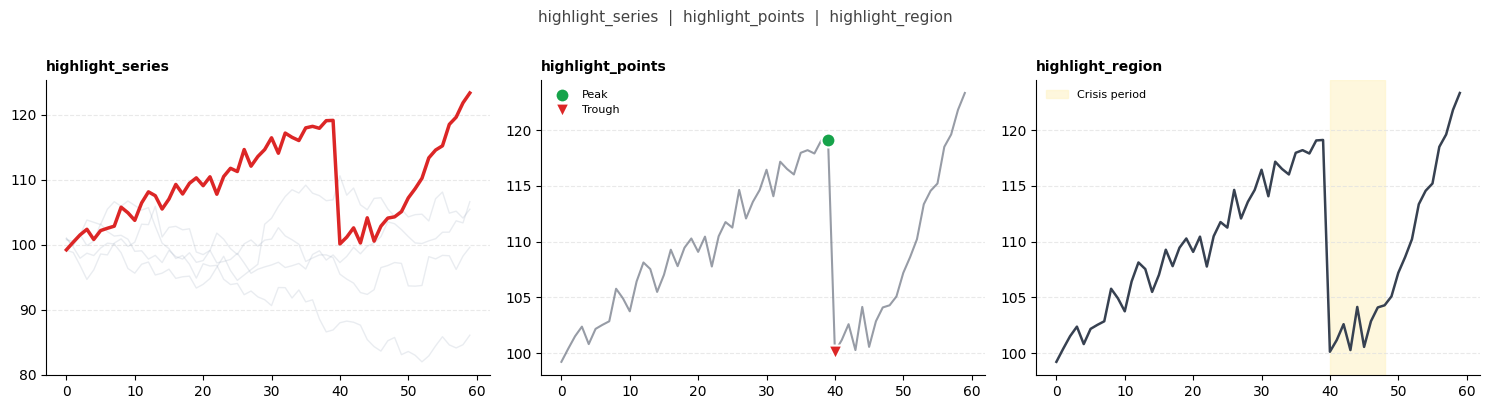

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='white')
fig.suptitle('highlight_series  |  highlight_points  |  highlight_region',
             fontsize=11, color='#444444', y=1.01)

# Panel 1 — highlight_series
ax = axes[0]
for name, y in bg_series.items():
    fade_series(ax, t, y, alpha=0.2)
highlight_series(ax, t, y_signal, color='#DC2626', linewidth=2.5)
ax.set_title('highlight_series', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

# Panel 2 — highlight_points (đỉnh và đáy)
ax = axes[1]
ax.plot(t, y_signal, color='#6B7280', linewidth=1.5, alpha=0.7)
# Đỉnh: tháng 39, Đáy: tháng 43
peak_idx  = np.argmax(y_signal[:45])
trough_idx = 40 + np.argmin(y_signal[40:50])
highlight_points(ax, [t[peak_idx]], [y_signal[peak_idx]],
                 color='#16A34A', size=100, label='Peak')
highlight_points(ax, [t[trough_idx]], [y_signal[trough_idx]],
                 color='#DC2626', size=100, marker='v', label='Trough')
ax.legend(frameon=False, fontsize=8)
ax.set_title('highlight_points', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

# Panel 3 — highlight_region
ax = axes[2]
ax.plot(t, y_signal, color='#374151', linewidth=1.8)
highlight_region(ax, xmin=40, xmax=48, color='#FEF3C7', alpha=0.6, label='Crisis period')
ax.legend(frameon=False, fontsize=8)
ax.set_title('highlight_region', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

### Nhận xét

Ba kỹ thuật highlight giúp nhấn mạnh đúng phần quan trọng mà không làm thay đổi toàn bộ biểu đồ.
Mỗi kỹ thuật phù hợp với một loại thông tin khác nhau: toàn bộ xu hướng, điểm cụ thể, hoặc một giai đoạn.

---

### highlight_series

Làm nổi bật toàn bộ một đường so với các đường còn lại.

Ưu điểm:
- xác định rõ series chính
- giữ các series khác làm background
- giảm cạnh tranh thị giác
- dễ theo dõi xu hướng chính

Lợi ích:
- người xem tập trung ngay vào đường quan trọng
- dễ so sánh với context xung quanh
- biểu đồ rõ ràng khi có nhiều series

---

### highlight_points

Đánh dấu các điểm cụ thể trên đường bằng markers.

Ưu điểm:
- nhấn mạnh peak / trough / outlier
- không ảnh hưởng toàn bộ series
- dễ chỉ ra sự kiện quan trọng
- giữ nguyên cấu trúc biểu đồ

Lợi ích:
- làm nổi bật turning points
- giúp người xem chú ý đúng vị trí
- hỗ trợ giải thích các biến động lớn

---

### highlight_region

Tô màu một khoảng trên trục x để nhấn mạnh một giai đoạn.

Ưu điểm:
- làm nổi bật một khoảng thời gian cụ thể
- không thay đổi style của series
- phù hợp để highlight event window
- giữ nguyên dữ liệu gốc

Lợi ích:
- người xem tập trung vào giai đoạn quan trọng
- dễ liên hệ với sự kiện theo timeline
- làm rõ trước / trong / sau một biến cố

## 3. Fade — Push to Background

Fade được dùng để giảm độ nổi bật của các thành phần phụ, giữ chúng làm context nhưng không cạnh tranh với signal.
Sau khi toàn bộ background được làm mờ, signal được vẽ đậm lên trên sẽ tạo trọng tâm rõ ràng.

---

### fade_series

Vẽ các series phụ với alpha thấp ngay từ đầu.

Đặc điểm:
- áp dụng khi plot mới từ đầu
- các đường background được kiểm soát ngay khi vẽ
- signal được vẽ sau cùng với style nổi bật

Ưu điểm:
- hierarchy rõ ràng ngay từ đầu
- tránh nhiều màu gây rối mắt
- giữ context nhẹ nhàng phía sau
- dễ highlight một hoặc nhiều signal

Phù hợp khi:
- biết trước đâu là signal
- vẽ nhiều series cùng lúc
- muốn kiểm soát style thống nhất

---

### fade_background_lines

Làm mờ các lines đã có sẵn trong axes sau khi plot.

Đặc điểm:
- áp dụng sau khi đã vẽ biểu đồ
- chỉnh trực tiếp các line trong axes
- không cần vẽ lại dữ liệu

Ưu điểm:
- linh hoạt khi thay đổi focus
- không cần viết lại code plot
- phù hợp exploratory workflow
- dễ highlight lại một series bất kỳ

Phù hợp khi:
- đã plot tất cả series trước
- chọn signal sau khi quan sát
- cần chỉnh lại hierarchy nhanh

---

### Kết quả sau khi fade

- các line background mờ đi
- signal giữ màu đậm và linewidth lớn
- signal nằm trên cùng (z-order cao)
- biểu đồ có trọng tâm rõ ràng

Hiệu ứng đạt được:
- focus-on-one
- giảm cạnh tranh thị giác
- giữ context nhưng không gây nhiễu
- tăng khả năng đọc khi nhiều series

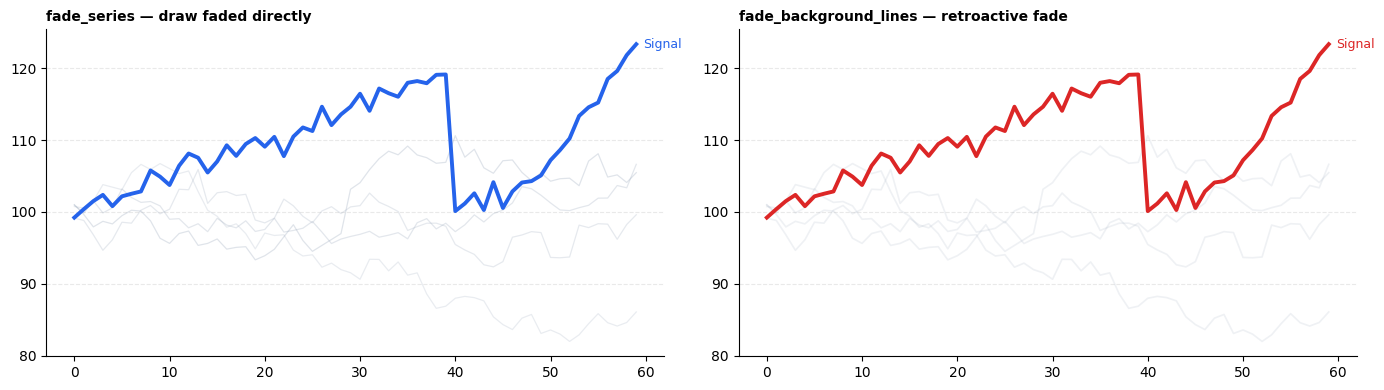

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')

# Panel 1 — fade khi vẽ
ax = axes[0]
for i, (name, y) in enumerate(bg_series.items()):
    fade_series(
        ax, t, y,
        color='#94A3B8',
        alpha=0.2 + i * 0.03,
        linewidth=0.9
    )

highlight_series(ax, t, y_signal, color='#2563EB', linewidth=2.8)
label_last_point(ax, t, y_signal, text='Signal', color='#2563EB')

ax.set_title('fade_series — draw faded directly', loc='left',
             fontsize=10, fontweight='bold')

despine(ax)
set_grid(ax)


# Panel 2 — vẽ tất cả → fade background → highlight signal
ax = axes[1]

# vẽ tất cả trước
for name, y in bg_series.items():
    ax.plot(t, y, color='#94A3B8', linewidth=1.2)

# vẽ signal (sẽ bị fade)
ax.plot(t, y_signal, color='#94A3B8', linewidth=1.2)

# fade toàn bộ lines đã có
fade_background_lines(ax, alpha=0.15, color='#94A3B8')

# highlight lại signal
highlight_series(ax, t, y_signal, color='#DC2626', linewidth=2.8)
label_last_point(ax, t, y_signal, text='Signal', color='#DC2626')

ax.set_title('fade_background_lines — retroactive fade', loc='left',
             fontsize=10, fontweight='bold')

despine(ax)
set_grid(ax)

plt.tight_layout()
plt.show()

# Nhận xét: `fade_series` vs `fade_background_lines`

## Mục đích chung

Cả hai kỹ thuật đều hướng đến cùng một mục tiêu trực quan: **làm nổi bật một đường tín hiệu quan trọng** bằng cách đẩy các đường nền xuống mờ hơn. Kết quả cuối cùng trông gần như giống hệt nhau, nhưng triết lý thiết kế và tình huống áp dụng lại khác nhau rõ rệt.

---

## `fade_series` — Kiểm soát từ đầu

Cách tiếp cận này theo tư duy **"biết trước, vẽ có chủ đích"**. Người viết code đã phân loại rõ ràng đường nào là nền, đường nào là signal ngay từ lúc vẽ. Alpha được truyền vào trực tiếp khi khởi tạo từng đường.

**Ưu điểm:**
- Code rõ ràng, dễ đọc — mỗi đường có style được định nghĩa tường minh
- Có thể kiểm soát alpha khác nhau cho từng đường nền
- Không cần bước xử lý hậu kỳ

**Hạn chế:**
- Phải biết trước đường nào là nền trước khi vẽ
- Kém linh hoạt nếu vai trò các đường thay đổi động

---

## `fade_background_lines` — Linh hoạt hậu kỳ

Cách tiếp cận này theo tư duy **"vẽ trước, quyết định sau"**. Toàn bộ đường được vẽ bình thường, sau đó một hàm xử lý hậu kỳ thay đổi alpha của tất cả `Line2D` objects trong axes, rồi mới vẽ đè signal lên.

**Ưu điểm:**
- Linh hoạt — có thể highlight bất kỳ đường nào sau khi đã vẽ xong
- Hữu ích trong pipeline tự động hoặc khi đường cần highlight được xác định muộn
- Dễ tích hợp vào workflow có sẵn mà không cần refactor logic vẽ

**Hạn chế:**
- Ít kiểm soát hơn — khó fade từng đường nền với mức alpha khác nhau
- Logic bị tách rời, đọc code cần theo dõi nhiều bước hơn

---

## So sánh tổng quan

| Tiêu chí | `fade_series` | `fade_background_lines` |
|---|---|---|
| Thời điểm fade | Khi vẽ | Sau khi vẽ xong |
| Kiểm soát alpha | Từng đường riêng lẻ | Toàn bộ một lúc |
| Tính linh hoạt | Thấp hơn | Cao hơn |
| Độ rõ ràng của code | Cao | Trung bình |
| Use case phù hợp | Biết trước nền/signal | Highlight linh hoạt hậu kỳ |
| Kết quả visual | Tương đương | Tương đương |

---

## Kết luận

Nếu pipeline của bạn đã xác định rõ đường nào là signal từ đầu, **`fade_series` là lựa chọn sạch hơn**. Nếu bạn cần highlight một đường bất kỳ sau khi đã vẽ toàn bộ — ví dụ trong dashboard động hoặc khi người dùng chọn series — thì **`fade_background_lines` linh hoạt và thực tiễn hơn**.

## 4. Focus-and-Context

Khi cần nhấn mạnh một giai đoạn cụ thể nhưng vẫn giữ toàn bộ dữ liệu, có thể dùng kỹ thuật focus-and-context.
Vùng quan trọng được làm nổi bật, phần còn lại vẫn hiển thị nhưng giảm độ chú ý.

---

### focus_on_range

Tô sáng trực tiếp vùng cần chú ý bằng background màu nhạt và đường biên dọc.

Ưu điểm:
- xác định rõ khoảng thời gian quan trọng
- không làm thay đổi style của các series
- giữ nguyên toàn bộ dữ liệu
- dễ kết hợp với highlight_series

Lợi ích:
- người xem tập trung vào giai đoạn chính
- vẫn so sánh được trước và sau
- phù hợp highlight event window hoặc regime change

---

### blur_outside_range

Làm mờ phần ngoài vùng focus bằng overlay trắng với alpha thấp.

Ưu điểm:
- giảm độ nổi bật của phần ngoài
- tạo cảm giác spotlight rõ ràng
- giữ nguyên cấu trúc biểu đồ
- không cần chỉnh từng series

Lợi ích:
- tăng tương phản giữa focus và context
- giúp mắt người không bị phân tán
- phù hợp khi focus rất ngắn

---

### Kết hợp hai hàm

Khi dùng cùng nhau:
- vùng focus được tô sáng
- vùng ngoài bị làm mờ
- tạo hiệu ứng spotlight rõ ràng

Kết quả:
- người xem nhìn ngay vào khoảng quan trọng
- vẫn giữ full context
- biểu đồ dễ đọc theo timeline
- không cần thay đổi dữ liệu hoặc series

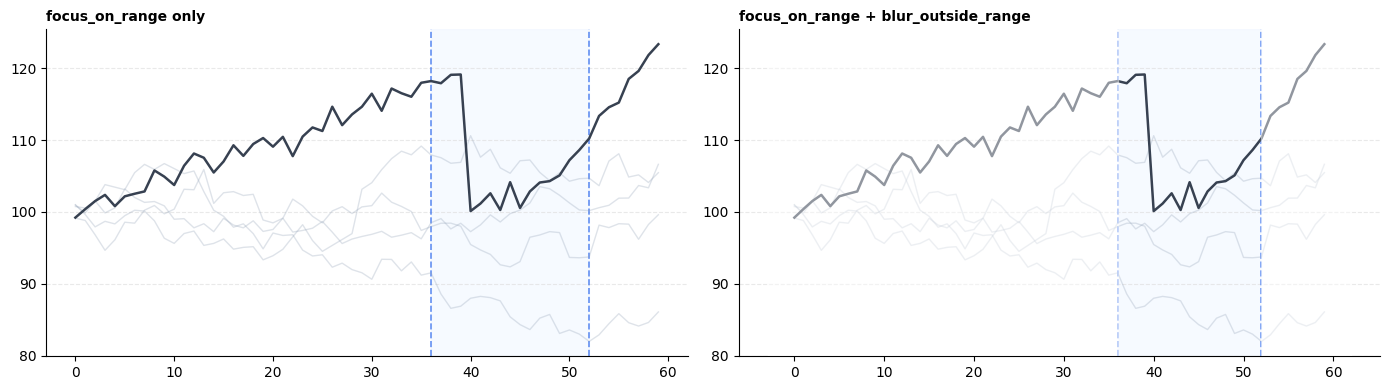

In [20]:
from vizint.perception.focus import focus_on_range, blur_outside_range

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')

FOCUS_START, FOCUS_END = 36, 52   # giai đoạn crisis + recovery

for ax, title, use_blur in zip(
    axes,
    ['focus_on_range only', 'focus_on_range + blur_outside_range'],
    [False, True]
):
    for name, y in bg_series.items():
        ax.plot(t, y, color='#94A3B8', linewidth=1.0, alpha=0.3)
    ax.plot(t, y_signal, color='#374151', linewidth=1.8)

    # Focus region
    focus_on_range(ax, FOCUS_START, FOCUS_END,
                   highlight_color='#EFF6FF', alpha=0.5,
                   border_color='#2563EB', border_linewidth=1.2)

    if use_blur:
        blur_outside_range(ax, FOCUS_START, FOCUS_END,
                           blur_alpha=0.45)

    ax.set_title(title, loc='left', fontsize=10, fontweight='bold')
    despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

### Nhận xét

Kỹ thuật focus-and-context giúp nhấn mạnh một giai đoạn cụ thể mà vẫn giữ đầy đủ context.
Vùng quan trọng nổi bật hơn, trong khi phần còn lại giảm mức độ chú ý nhưng vẫn hiển thị.

### focus_on_range

Ưu điểm:
- đánh dấu rõ khoảng thời gian cần chú ý
- giữ nguyên toàn bộ dữ liệu
- không làm thay đổi style của series
- phù hợp highlight event window

Lợi ích:
- người xem nhận ra ngay vùng quan trọng
- vẫn so sánh được trước và sau
- biểu đồ dễ đọc theo timeline

### focus_on_range + blur_outside_range

Ưu điểm:
- vùng focus nổi bật hơn rõ rệt
- phần ngoài được đẩy xuống background
- giảm cạnh tranh thị giác
- tạo hierarchy theo thời gian

Lợi ích:
- mắt người tập trung vào vùng highlight
- giai đoạn quan trọng dễ nhận ra hơn
- biểu đồ có trọng tâm rõ ràng hơn

So với chỉ dùng focus_on_range, việc kết hợp blur_outside_range giúp hiệu ứng spotlight mạnh hơn và giảm nhiễu từ phần ngoài vùng focus.

## 5. Visual Hierarchy

Visual hierarchy giúp phân cấp mức độ quan trọng giữa các series để biểu đồ có trọng tâm rõ ràng.
Các thành phần chính nổi bật hơn, các thành phần phụ hỗ trợ, và phần còn lại làm context.

Phân cấp theo alpha, linewidth và z-order giúp giảm cạnh tranh thị giác giữa các đường.
Series quan trọng nổi bật ngay lập tức mà không cần thêm annotation.

Ưu điểm:
- tạo trọng tâm rõ ràng cho biểu đồ
- giảm nhiễu khi có nhiều series
- giữ được context tổng thể
- không cần thay đổi dữ liệu
- dễ đọc khi overlay nhiều đường

Lợi ích:
- người xem nhận ra insight chính nhanh hơn
- phân biệt rõ signal và context
- cải thiện khả năng so sánh
- biểu đồ có cấu trúc rõ ràng hơn

### Primary

Đường chính cần nhấn mạnh.

Đặc điểm:
- alpha cao
- linewidth lớn hơn
- z-order cao
- màu nổi bật

Vai trò:
- thể hiện insight chính
- thu hút sự chú ý đầu tiên

---

### Secondary

Thông tin hỗ trợ cho primary.

Đặc điểm:
- alpha trung bình
- linewidth bình thường
- z-order trung bình
- màu nhẹ hơn primary

Vai trò:
- hỗ trợ so sánh
- cung cấp thêm thông tin

---

### Background

Context tổng thể.

Đặc điểm:
- alpha thấp
- linewidth nhỏ
- z-order thấp
- màu nhạt

Vai trò:
- giữ bối cảnh
- không cạnh tranh với primary

---

### emphasize_series

Tự động áp dụng visual hierarchy cho các lines trong axes.

Cách hoạt động:
- line thứ N → primary
- các line còn lại → background
- giữ nguyên dữ liệu gốc
- chỉ thay đổi style hiển thị

Ưu điểm:
- tạo hierarchy nhanh chóng
- không cần chỉnh từng line
- phù hợp khi có nhiều series
- dễ thay đổi series được highlight

Lợi ích:
- chuyển biểu đồ flat thành có trọng tâm
- giảm clutter thị giác
- highlight insight chính ngay lập tức

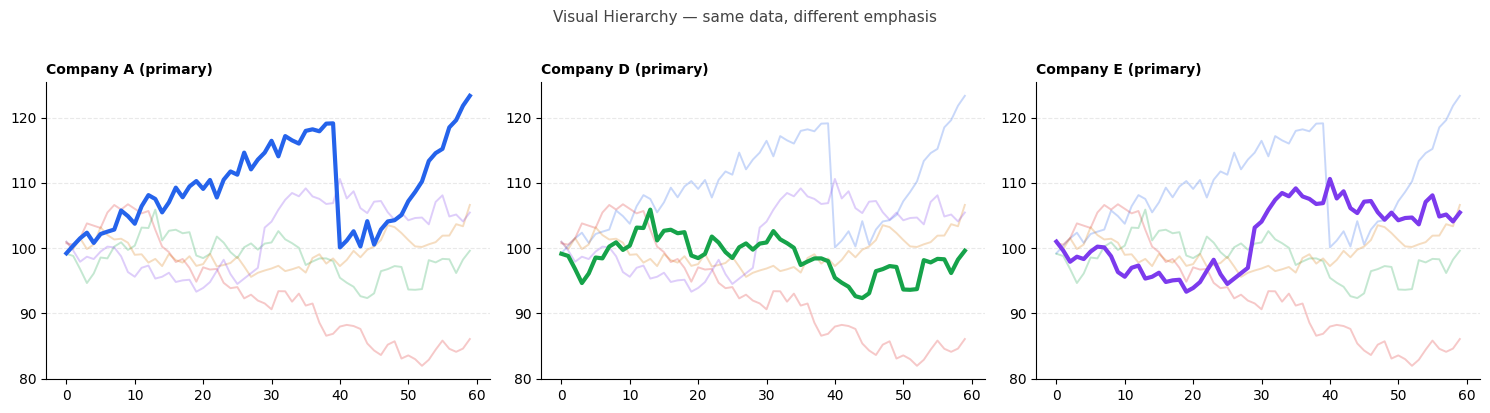

In [21]:
from vizint.styling.hierarchy import emphasize_series, set_emphasis

fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='white')
colors = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED']

all_y = [y_signal] + list(bg_series.values())
all_names = ['Company A'] + list(bg_series.keys())

for ax_idx, (ax, focus_i, focus_name) in enumerate(zip(
    axes,
    [0, 2, 4],
    ['Company A (primary)', 'Company D (primary)', 'Company E (primary)']
)):
    # Vẽ tất cả
    for i, (name, y, c) in enumerate(zip(all_names, all_y, colors)):
        ax.plot(t, y, color=c, linewidth=2.0, label=name)

    # Phân cấp: focus_i là primary, còn lại là background
    emphasize_series(ax, keep_index=focus_i,
                     level_keep='primary', level_rest='background')

    ax.set_title(focus_name, loc='left', fontsize=10, fontweight='bold')
    despine(ax); set_grid(ax)

fig.suptitle('Visual Hierarchy — same data, different emphasis',
             fontsize=11, color='#444', y=1.02)
plt.tight_layout()
plt.show()

### Nhận xét

Visual hierarchy cho phép nhấn mạnh các series khác nhau mà không cần thay đổi dữ liệu.
Cùng một chart nhưng chỉ cần thay đổi mức độ nổi bật là có thể chuyển trọng tâm sang insight khác.

### Ưu điểm

- làm nổi bật insight chính mà không loại bỏ context
- giảm cạnh tranh thị giác giữa nhiều series
- linh hoạt thay đổi trọng tâm phân tích
- giữ nguyên cấu trúc biểu đồ
- dễ đọc khi overlay nhiều đường
- không cần thêm annotation

### Lợi ích

- cùng một dữ liệu có thể kể nhiều câu chuyện khác nhau
- người xem tập trung vào đúng series cần phân tích
- so sánh từng đối tượng trong cùng context
- chuyển đổi focus nhanh mà không vẽ lại chart
- cải thiện khả năng trình bày khi báo cáo nhiều góc nhìn

Trong ví dụ:
- panel 1 nhấn mạnh Company A → thấy xu hướng tăng mạnh
- panel 2 nhấn mạnh Company D → thấy biến động trung bình
- panel 3 nhấn mạnh Company E → thấy pattern khác biệt

Cùng dữ liệu nhưng hierarchy khác nhau làm nổi bật insight khác nhau.

## 6. Saliency Encoding

Saliency encoding giúp biểu diễn mức độ quan trọng của từng điểm dữ liệu trực tiếp trên chart.
Các điểm quan trọng hơn được làm nổi bật bằng màu sắc mạnh hơn và kích thước lớn hơn.

### Nhận xét

Việc encode saliency bằng cả màu sắc và kích thước giúp các điểm quan trọng nổi bật rõ ràng hơn.
Các điểm ít quan trọng vẫn hiển thị nhưng không cạnh tranh sự chú ý.

### Ưu điểm

- nhấn mạnh mức độ quan trọng theo từng điểm
- thể hiện được sự khác biệt liên tục của saliency
- không cần thêm annotation hoặc label
- giữ nguyên toàn bộ dữ liệu
- dễ nhận ra outlier hoặc peak quan trọng

### Lợi ích

- người xem nhận ra điểm quan trọng ngay lập tức
- tăng khả năng đọc khi dữ liệu dày đặc
- phân biệt rõ mức độ quan trọng giữa các điểm
- phù hợp highlight anomaly hoặc event
- giúp chart truyền đạt insight trực quan hơn

### Encoding

saliency thấp:
- màu vàng nhạt
- marker nhỏ
- ít nổi bật

saliency cao:
- màu đỏ đậm
- marker lớn
- nổi bật rõ ràng

Sử dụng đồng thời màu sắc và kích thước giúp các điểm có saliency cao trở thành trọng tâm ngay trên chart.

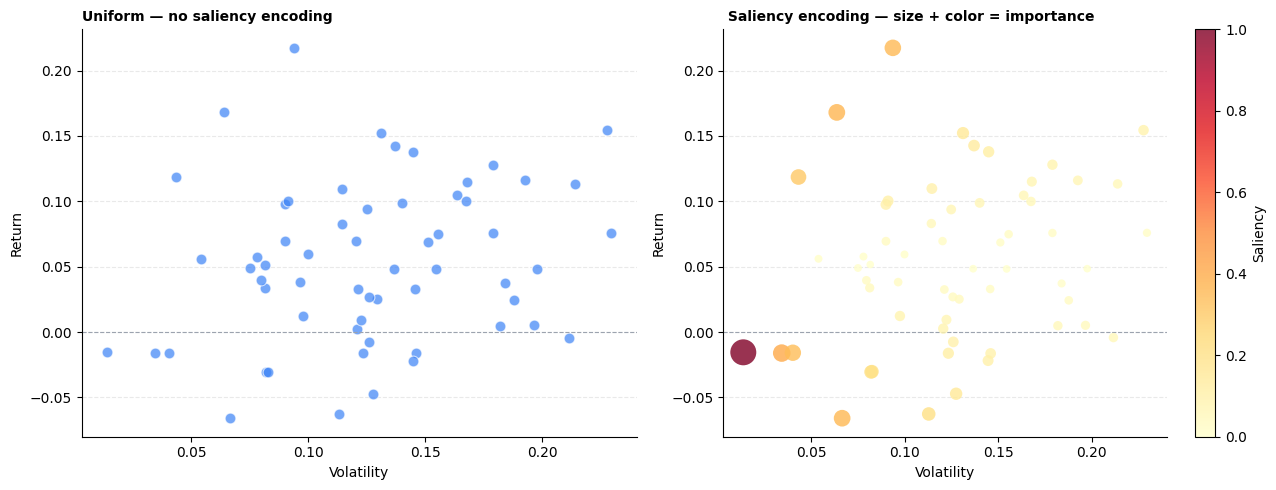

In [22]:
# Tạo scatter data — 2D portfolio returns
n_assets = 60
returns   = np.random.randn(n_assets) * 0.08 + 0.05
volatility = np.abs(np.random.randn(n_assets) * 0.05 + 0.12)

# Saliency = |return - mean| / volatility  (risk-adjusted deviation)
saliency = np.abs(returns - returns.mean()) / volatility

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

# Panel 1: uniform scatter — không saliency
ax = axes[0]
ax.scatter(volatility, returns, color='#3B82F6', s=60, alpha=0.7, edgecolors='white', linewidths=0.8)
ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--')
ax.set_xlabel('Volatility'); ax.set_ylabel('Return')
ax.set_title('Uniform — no saliency encoding', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

# Panel 2: saliency encoding
ax = axes[1]
saliency_map_scatter(ax, volatility, returns, saliency,
                     cmap='YlOrRd', size_range=(30, 350),
                     alpha=0.8, colorbar=True)
ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--')
ax.set_xlabel('Volatility'); ax.set_ylabel('Return')
ax.set_title(' Saliency encoding — size + color = importance', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

### Nhận xét

Saliency encoding giúp thể hiện mức độ quan trọng của từng điểm thay vì xem tất cả điểm như nhau.
Các điểm quan trọng nổi bật ngay lập tức, trong khi các điểm ít quan trọng được đẩy xuống background.

### Ưu điểm

- làm nổi bật điểm quan trọng trong scatter dày đặc
- phân biệt rõ mức độ quan trọng giữa các điểm
- không cần thêm annotation
- giữ toàn bộ dữ liệu
- tăng tương phản thị giác

### Lợi ích

- người xem nhận ra outlier ngay lập tức
- dễ phát hiện điểm có ý nghĩa cao
- giảm nhiễu từ các điểm ít quan trọng
- cải thiện khả năng đọc scatter plot
- giúp truyền đạt insight trực quan hơn

So với uniform scatter:
- tất cả điểm có trọng số như nhau
- khó nhận ra điểm quan trọng

Khi dùng saliency encoding:
- điểm quan trọng lớn hơn và đậm hơn
- điểm ít quan trọng nhỏ và nhạt
- hierarchy theo từng điểm được tạo rõ ràng

## 7. Outlier Detection & Emphasis

Outlier có thể là điểm lỗi hoặc điểm mang ý nghĩa đặc biệt, vì vậy cần được phát hiện và làm nổi bật thay vì bị hòa lẫn vào các điểm khác. Việc vừa detect vừa emphasize giúp outlier dễ nhận ra nhưng vẫn giữ nguyên dữ liệu gốc.

Phát hiện outlier bằng quy tắc thống kê giúp tránh highlight thủ công. Sau khi phát hiện, việc thêm ring nhấn mạnh giúp tăng saliency mà không làm thay đổi marker ban đầu.

---

### emphasize_outliers

Thêm vòng ring xung quanh outlier để tăng độ nổi bật. Cần được gọi **trước** `detect_and_mark_outliers` để ring không đè lên marker chính.

Ưu điểm:
- giữ nguyên marker gốc
- tăng saliency mà không đổi màu chính
- không làm rối biểu đồ
- dễ phân biệt với điểm thường

Lợi ích:
- outlier nổi bật ngay lập tức
- giữ context đầy đủ
- cải thiện khả năng đọc scatter plot và time series

> **Lưu ý:** Độ rõ của ring phụ thuộc vào `ring_color` và màu nền biểu đồ. Nên chọn màu có độ tương phản đủ cao để ring hiển thị rõ ràng.

---

### detect_and_mark_outliers

Tự động xác định các điểm nằm ngoài phạm vi thông thường và đánh dấu chúng bằng marker. Cần được gọi **sau** `emphasize_outliers` để marker không bị ring che khuất.

Ưu điểm:
- phát hiện outlier tự động
- không cần chọn thủ công
- áp dụng được cho scatter hoặc time series
- giữ nguyên dữ liệu gốc

Lợi ích:
- phát hiện anomaly nhanh
- tránh bỏ sót điểm quan trọng
- hỗ trợ phân tích dữ liệu thăm dò

Hỗ trợ hai phương pháp phát hiện qua tham số `method`:

---

### method = "iqr"

Dựa trên khoảng tứ phân vị (IQR) để xác định ngưỡng. Một điểm bị coi là outlier nếu nằm ngoài `[Q1 - threshold×IQR, Q3 + threshold×IQR]`.

Ưu điểm:
- không giả định phân phối chuẩn
- ổn định với dữ liệu lệch (skewed)
- ít bị ảnh hưởng bởi extreme values
- phù hợp dữ liệu thực tế

Lợi ích:
- phát hiện outlier đáng tin cậy hơn với skewed data
- tránh đánh dấu quá nhiều điểm

---

### method = "zscore"

Dựa trên độ lệch chuẩn so với trung bình. Một điểm bị coi là outlier nếu `|z| > threshold`.

Ưu điểm:
- đơn giản và nhanh
- dễ điều chỉnh threshold
- phù hợp phân phối gần normal
- nhạy hơn với deviation lớn so với IQR

Lợi ích:
- phát hiện điểm cực trị rõ ràng
- phù hợp dữ liệu đã chuẩn hóa
- có thể bắt thêm outlier mà IQR bỏ qua ở vùng biên

> **So sánh hai method:** IQR bền vững hơn với dữ liệu thực tế không chuẩn, còn z-score nhạy hơn và phù hợp khi dữ liệu gần phân phối normal. Cùng một dataset, z-score thường phát hiện nhiều outlier hơn IQR ở cùng mức threshold tương đương.

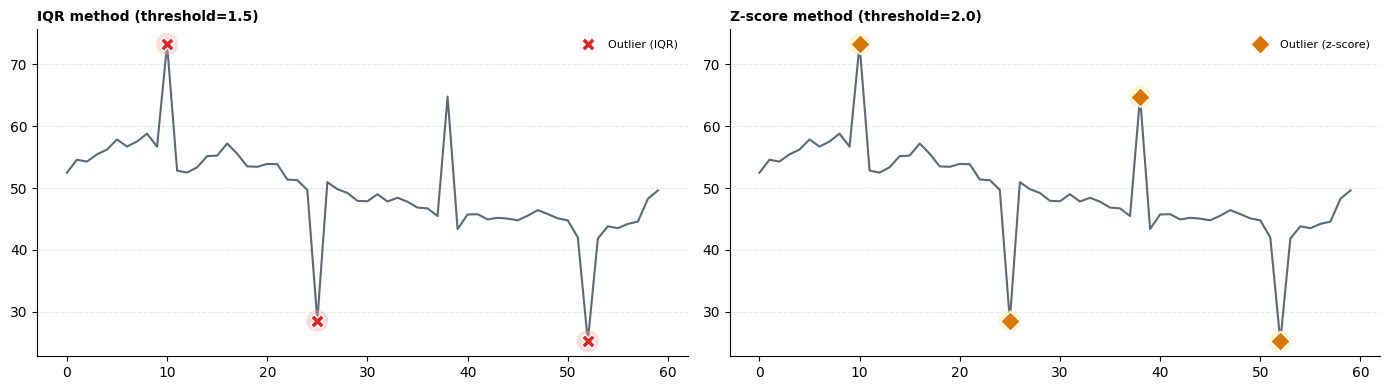

In [23]:
from vizint.perception.outlier import detect_and_mark_outliers, emphasize_outliers

# Tạo series với outlier nhân tạo
y_clean   = 50 + np.cumsum(np.random.randn(T) * 1.2)
y_with_ol = y_clean.copy()
outlier_idx = [10, 25, 38, 52]   # inject outliers
y_with_ol[outlier_idx] += np.array([18, -22, 20, -15])

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')

# Panel 1: IQR method
ax = axes[0]
ax.plot(t, y_with_ol, color='#374151', linewidth=1.5, alpha=0.8)
emphasize_outliers(ax, t, y_with_ol, method='iqr', threshold=1.5, ring_color='#FCA5A5')
detect_and_mark_outliers(ax, t, y_with_ol, method='iqr', threshold=1.5,
                         marker_color='#DC2626', label='Outlier (IQR)')
ax.legend(frameon=False, fontsize=8)
ax.set_title('IQR method (threshold=1.5)', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

# Panel 2: Z-score method
ax = axes[1]
ax.plot(t, y_with_ol, color='#374151', linewidth=1.5, alpha=0.8)
emphasize_outliers(ax, t, y_with_ol, method='zscore', threshold=2.0, ring_color='#FDE68A')
detect_and_mark_outliers(ax, t, y_with_ol, method='zscore', threshold=2.0,
                         marker_color='#D97706', marker='D', label='Outlier (z-score)')
ax.legend(frameon=False, fontsize=8)
ax.set_title('Z-score method (threshold=2.0)', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

### Nhận xét hình minh họa

Nhìn vào kết quả render, có **2 vấn đề trực quan** cần lưu ý:

---

#### Ring không hiển thị

`emphasize_outliers` được gọi nhưng **hoàn toàn không thấy ring/halo** quanh bất kỳ outlier nào ở cả hai panel. Nguyên nhân có thể là:
- `ring_color='#FCA5A5'` và `#FDE68A` quá nhạt trên nền trắng
- Size của ring quá nhỏ so với marker
- Alpha của ring quá thấp

---

#### IQR bỏ sót outlier tại x≈38

Theo code, 4 điểm được inject: `[10, 25, 38, 52]`. Nhưng IQR (panel trái) chỉ bắt được **3 điểm** — bỏ qua x≈38 dù điểm đó tăng `+20`. Z-score (panel phải) bắt đủ cả 4.

Điều này đúng với lý thuyết IQR ổn định hơn, nhưng ở đây lại thành **bỏ sót** thay vì ưu điểm — vì x≈38 thực sự là outlier được inject có chủ đích.

---

#### Gợi ý sửa

| Vấn đề | Hướng sửa |
|---|---|
| Ring không thấy | Tăng alpha, size ring; đổi màu đậm hơn |
| IQR bỏ x≈38 | Giảm threshold xuống `1.2` hoặc dùng z-score cho demo này |

## 8. Putting It All Together — Full Perception Stack

Kết hợp toàn bộ kỹ thuật perception trong một chart duy nhất để tạo ra một biểu đồ vừa đẹp, vừa truyền tải thông tin rõ ràng và có chủ đích. Mỗi lớp kỹ thuật giải quyết một vấn đề nhận thức khác nhau, và khi xếp chồng lên nhau theo đúng thứ tự, chúng tạo ra một hierarchy thị giác hoàn chỉnh.

---

### Thứ tự áp dụng

Thứ tự thực thi rất quan trọng — các lớp phía sau sẽ đè lên lớp phía trước. Quy tắc chung: **vẽ nền trước, highlight sau, annotation cuối cùng**.

---

### 1. Fade noise series xuống background

Đưa các series không quan trọng xuống nền bằng cách giảm alpha và độ đậm của nét vẽ. Mục tiêu là giữ context mà không cạnh tranh sự chú ý với signal chính.

- Dùng `fade_series` hoặc `fade_background_lines`
- Alpha nền nên ở mức `0.15–0.3`
- Màu nên trung tính: `#94A3B8`, `#CBD5E1`

---

### 2. Highlight signal series

Vẽ đường tín hiệu chính với độ đậm và màu sắc nổi bật để tách biệt hoàn toàn khỏi nền.

- Dùng `highlight_series`
- Linewidth nên gấp 2–3 lần đường nền
- Chọn màu có độ tương phản cao: `#2563EB`, `#DC2626`

---

### 3. Focus vào giai đoạn quan trọng

Dùng vùng tô màu hoặc annotation để kéo ánh mắt người đọc vào đúng khoảng thời gian cần phân tích, thay vì để họ tự quét toàn bộ trục x.

- Dùng `focus_band` hoặc `ax.axvspan`
- Alpha vùng focus: `0.08–0.15`
- Kết hợp với nhãn giải thích ngắn gọn

---

### 4. Mark turning points (đỉnh + đáy)

Đánh dấu các điểm đảo chiều quan trọng bằng marker để người đọc nhận ra cấu trúc của series mà không cần đọc từng điểm dữ liệu.

- Dùng `mark_turning_points` với `order` phù hợp để kiểm soát độ nhạy
- Phân biệt đỉnh và đáy bằng marker khác nhau hoặc màu khác nhau
- Tránh đánh dấu quá nhiều điểm — chỉ giữ lại các đỉnh/đáy có ý nghĩa

---

### 5. Label điểm cuối

Gán nhãn trực tiếp lên điểm cuối của series thay vì dùng legend, giúp người đọc biết ngay đường nào là đường nào mà không cần tra cứu.

- Dùng `label_last_point`
- Màu nhãn nên trùng với màu đường
- Canh lề nhãn ra ngoài vùng data để không che dữ liệu

---

### 6. Apply theme để hoàn thiện styling

Áp dụng theme thống nhất cuối cùng để đảm bảo toàn bộ chart có ngôn ngữ thiết kế nhất quán.

- Dùng `despine` để xóa border thừa
- Dùng `set_grid` để thêm gridline nhẹ làm nền tham chiếu
- Kiểm tra font size, linewidth, và màu sắc có nhất quán xuyên suốt

---

### Nguyên tắc kết hợp

| Lớp | Công cụ | Mục đích |
|---|---|---|
| Fade background | `fade_series` / `fade_background_lines` | Giảm noise, giữ context |
| Highlight signal | `highlight_series` | Tạo focal point chính |
| Focus band | `focus_band` / `axvspan` | Dẫn dắt ánh mắt theo thời gian |
| Turning points | `mark_turning_points` | Lộ cấu trúc của series |
| End label | `label_last_point` | Định danh trực tiếp |
| Theme | `despine` + `set_grid` | Thống nhất ngôn ngữ thiết kế |

> **Lưu ý:** Không phải lúc nào cũng cần dùng tất cả 6 lớp. Chọn lọc kỹ thuật phù hợp với câu chuyện dữ liệu cần kể — thêm quá nhiều lớp có thể gây rối thay vì làm rõ.

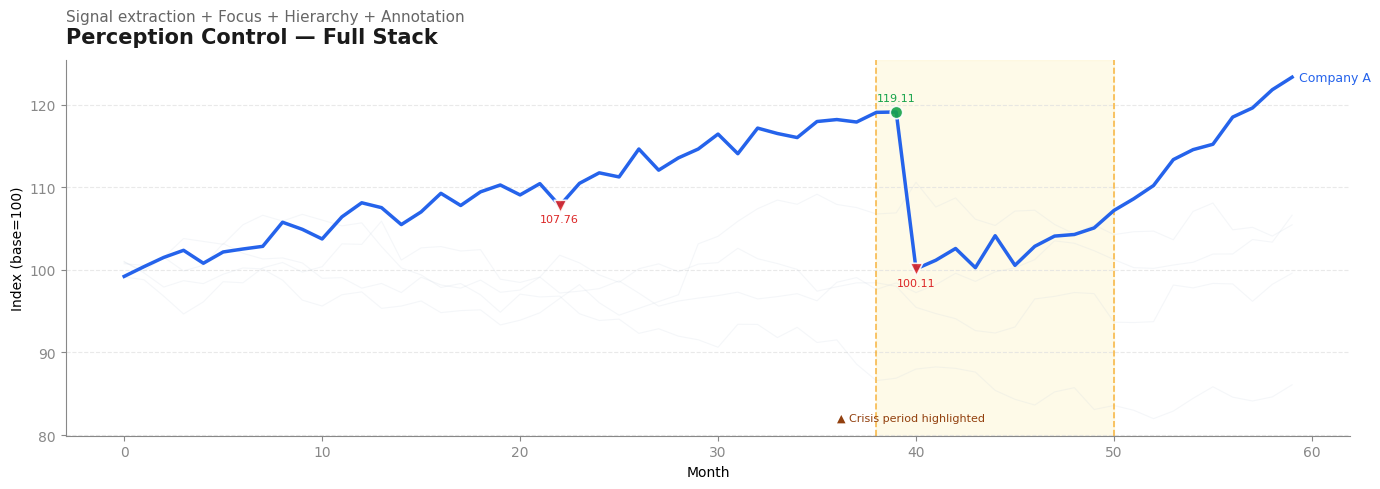

In [24]:
from vizint.narrative.turning_point import mark_turning_points
from vizint.annotation import add_note, add_caption

chart = (
    ChartBuilder(figsize=(14, 5))
    .set_title('Perception Control — Full Stack')
    .set_subtitle('Signal extraction + Focus + Hierarchy + Annotation')
    .build()
)
ax = chart.ax

# Layer 1: Noise
for name, y in bg_series.items():
    fade_series(ax, t, y, color='#CBD5E1', alpha=0.2, linewidth=0.8)

# Layer 2: Signal
highlight_series(ax, t, y_signal, color='#2563EB', linewidth=2.5, label='Company A')

# Layer 3: Focus period (crisis window)
focus_on_range(ax, 38, 50, highlight_color='#FEF3C7', alpha=0.4,
               border_color='#F59E0B', border_linewidth=1.2)

# Layer 4: Turning points
mark_turning_points(ax, t, y_signal, order=4,
                    max_color='#16A34A', min_color='#DC2626', show_labels=True)

# Layer 5: Label
label_last_point(ax, t, y_signal, text='Company A', color='#2563EB')

# Annotation
add_note(ax, '▲ Crisis period highlighted', x=0.60, y=0.06,
         color='#92400E', fontsize=8)

ax.set_xlabel('Month')
ax.set_ylabel('Index (base=100)')

plt.tight_layout()
plt.show()

### Nhận xét

Hình thể hiện đầy đủ và rõ ràng triết lý **Full Perception Stack** — mỗi lớp kỹ thuật đều có thể nhận diện được trực tiếp trên chart.

---

**Hierarchy thị giác rõ ràng:**
- Signal chính (Company A) nổi bật với đường xanh đậm, linewidth lớn
- Các đường nền mờ nhạt đúng vai trò context, không cạnh tranh với signal

**Focus band hiệu quả:**
- Vùng vàng nhạt (tháng 38–50) khoanh vùng "Crisis period" rõ ràng
- Đường dashed border giúp xác định ranh giới chính xác hơn
- Nhãn "Crisis period highlighted" đặt bên dưới tránh che dữ liệu

**Turning points có chọn lọc:**
- Chỉ đánh dấu 2 điểm quan trọng nhất trong vùng crisis: đỉnh `119.11` và đáy `100.11`
- Mũi tên nối đỉnh–đáy giúp thấy ngay biên độ sụt giảm (~19 điểm)
- Đáy phụ `107.76` ở tháng 22 được mark nhẹ hơn — đúng với phân cấp quan trọng

**Label cuối series:**
- Nhãn "Company A" gắn trực tiếp vào điểm cuối, không dùng legend rời
- Màu nhãn trùng màu đường — nhất quán

**Title phân cấp rõ:**
- Subtitle nhỏ: `Signal extraction + Focus + Hierarchy + Annotation` — liệt kê đúng các lớp đã dùng
- Title lớn in đậm: `Perception Control — Full Stack`

---

#### Cải thiện

- Nhãn `107.76` ở tháng 22 hơi nhỏ và dễ bị bỏ qua — nếu không phải turning point quan trọng thì nên bỏ hẳn để giảm noise
- Vùng focus band kéo dài đến tháng 50 nhưng signal đã hồi phục từ tháng 45 — có thể thu hẹp lại để focus band khớp hơn với "crisis" thực sự

---
## Summary

| Technique | Function | Mục đích |
|-----------|----------|----------|
| Signal vs Noise | `highlight_series` + `fade_series` | Tách tín hiệu khỏi nhiễu |
| Point emphasis | `highlight_points` | Đánh dấu điểm dữ liệu cụ thể |
| Region emphasis | `highlight_region` | Thu hút vào giai đoạn cụ thể |
| Retroactive fade | `fade_background_lines` | Làm mờ lines đã có sẵn |
| Spotlight | `focus_on_range` + `blur_outside_range` | Hiệu ứng spotlight |
| Hierarchy | `emphasize_series` | Phân cấp primary / secondary / bg |
| Importance encoding | `saliency_map_scatter` | Encode importance = size + color |
| Anomaly detection | `detect_and_mark_outliers` | IQR hoặc z-score outlier detection |

---

### Key Takeaway

> Một chart tốt không phải là chart có đủ thông tin.
> Một chart tốt là chart **kiểm soát được thứ tự** mà người xem nhận thức thông tin.

**Next →** `02_narrative_visualization.ipynb` — Khi nào mọi thứ thay đổi: turning points, events, và story framing.